In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

from scipy.stats import linregress

In [2]:
nav = pd.read_csv(
    "../data/processed/nav_history_clean.csv"
)

performance = pd.read_csv(
    "../data/processed/performance_clean.csv"
)

benchmark = pd.read_csv(
    "../data/processed/benchmark_clean.csv"
)

nav["date"] = pd.to_datetime(
    nav["date"]
)

benchmark["date"] = pd.to_datetime(
    benchmark["date"]
)

In [3]:
nav = nav.sort_values(
    ["amfi_code", "date"]
)

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
    .pct_change()
)

nav["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

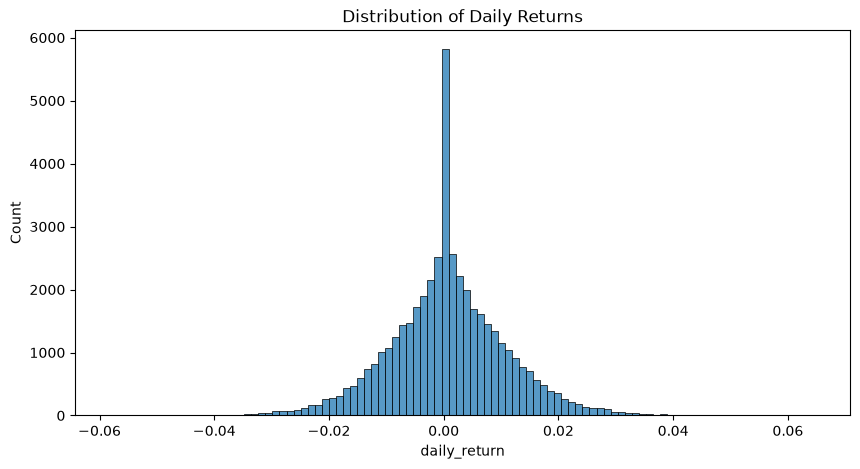

In [4]:
plt.figure(figsize=(10,5))

sns.histplot(
    nav["daily_return"].dropna(),
    bins=100
)

plt.title(
    "Distribution of Daily Returns"
)

plt.savefig(
    "../reports/daily_return_distribution.png"
)

plt.show()

In [5]:
cagr = []

for fund in nav["amfi_code"].unique():

    temp = nav[
        nav["amfi_code"] == fund
    ]

    start_nav = temp.iloc[0]["nav"]
    end_nav = temp.iloc[-1]["nav"]

    years = (
        temp["date"].max()
        -
        temp["date"].min()
    ).days / 365

    value = (
        (end_nav/start_nav)
        ** (1/years)
        -
        1
    )

    cagr.append(
        [fund, value]
    )

cagr = pd.DataFrame(
    cagr,
    columns=["amfi_code", "cagr"]
)

cagr.head()

,amfi_code,cagr
0,100016,0.026352
1,100025,0.044551
2,100033,0.300997
3,101206,0.235205
4,101207,0.079331


In [6]:
risk_free = 0.065

sharpe = []

for fund in nav["amfi_code"].unique():

    ret = nav[
        nav["amfi_code"] == fund
    ]["daily_return"].dropna()

    rp = ret.mean() * 252

    sigma = ret.std()

    sharpe_ratio = (
        (rp - risk_free)
        /
        sigma
    ) * np.sqrt(252)

    sharpe.append(
        [fund, sharpe_ratio]
    )

sharpe = pd.DataFrame(
    sharpe,
    columns=[
        "amfi_code",
        "sharpe_ratio"
    ]
)

In [7]:
sortino = []

for fund in nav["amfi_code"].unique():

    ret = nav[
        nav["amfi_code"] == fund
    ]["daily_return"].dropna()

    downside = ret[
        ret < 0
    ]

    downside_std = downside.std()

    rp = ret.mean() * 252

    ratio = (
        (rp - risk_free)
        /
        downside_std
    ) * np.sqrt(252)

    sortino.append(
        [fund, ratio]
    )

sortino = pd.DataFrame(
    sortino,
    columns=[
        "amfi_code",
        "sortino_ratio"
    ]
)

In [8]:
nifty = benchmark[
    benchmark["index_name"]
    ==
    "Nifty 100"
]

In [9]:
benchmark["date"] = pd.to_datetime(
    benchmark["date"]
)

benchmark = benchmark.sort_values(
    ["index_name", "date"]
)

benchmark["daily_return"] = (
    benchmark
    .groupby("index_name")["close_value"]
    .pct_change()
)

print(benchmark.head())

        date    index_name  close_value  daily_return
0 2022-01-03  BSE_SMALLCAP     26554.60           NaN
1 2022-01-04  BSE_SMALLCAP     27079.92      0.019783
2 2022-01-05  BSE_SMALLCAP     27313.35      0.008620
3 2022-01-06  BSE_SMALLCAP     27377.05      0.002332
4 2022-01-07  BSE_SMALLCAP     26316.86     -0.038726


In [10]:
print(
    benchmark["index_name"]
    .unique()
)

<StringArray>
[   'BSE_SMALLCAP',     'CRISIL_GILT',   'CRISIL_LIQUID',        'NIFTY100',
         'NIFTY50',        'NIFTY500', 'NIFTY_MIDCAP150']
Length: 7, dtype: str


In [11]:
nifty = benchmark[
    benchmark["index_name"]
    == "NIFTY100"
]

nifty = nifty.dropna(
    subset=["daily_return"]
)

print(len(nifty))
print(nifty.head())

1149
           date index_name  close_value  daily_return
3451 2022-01-04   NIFTY100     17537.52     -0.013540
3452 2022-01-05   NIFTY100     17607.73      0.004003
3453 2022-01-06   NIFTY100     17556.05     -0.002935
3454 2022-01-07   NIFTY100     17664.02      0.006150
3455 2022-01-10   NIFTY100     17516.51     -0.008351


In [12]:
alpha_beta = []

for fund in nav["amfi_code"].unique():

    ret = nav[
        nav["amfi_code"] == fund
    ]["daily_return"].dropna()

    n = min(
        len(ret),
        len(nifty)
    )

    x = nifty["daily_return"].values[:n]

    y = ret.values[:n]

    slope, intercept, r, p, stderr = linregress(
        x,
        y
    )

    alpha = intercept * 252

    alpha_beta.append(
        [fund, alpha, slope]
    )

alpha_beta = pd.DataFrame(
    alpha_beta,
    columns=[
        "amfi_code",
        "alpha",
        "beta"
    ]
)

alpha_beta.to_csv(
    "../data/processed/alpha_beta.csv",
    index=False
)

alpha_beta.head()

,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [13]:
drawdowns = []

for fund in nav["amfi_code"].unique():

    temp = nav[
        nav["amfi_code"] == fund
    ]

    running_max = temp["nav"].cummax()

    dd = (
        temp["nav"]
        /
        running_max
        -
        1
    )

    drawdowns.append(
        [fund, dd.min()]
    )

drawdowns = pd.DataFrame(
    drawdowns,
    columns=[
        "amfi_code",
        "max_drawdown"
    ]
)

In [14]:
score = (
    cagr
    .merge(sharpe)
    .merge(alpha_beta)
    .merge(drawdowns)
)

score["score"] = (
    score["cagr"].rank(pct=True)*30
    +
    score["sharpe_ratio"].rank(pct=True)*25
    +
    score["alpha"].rank(pct=True)*20
    +
    score["max_drawdown"].rank(
        pct=True,
        ascending=False
    )*25
)

score = score.sort_values(
    "score",
    ascending=False
)

score.to_csv(
    "../data/processed/fund_scorecard.csv",
    index=False
)

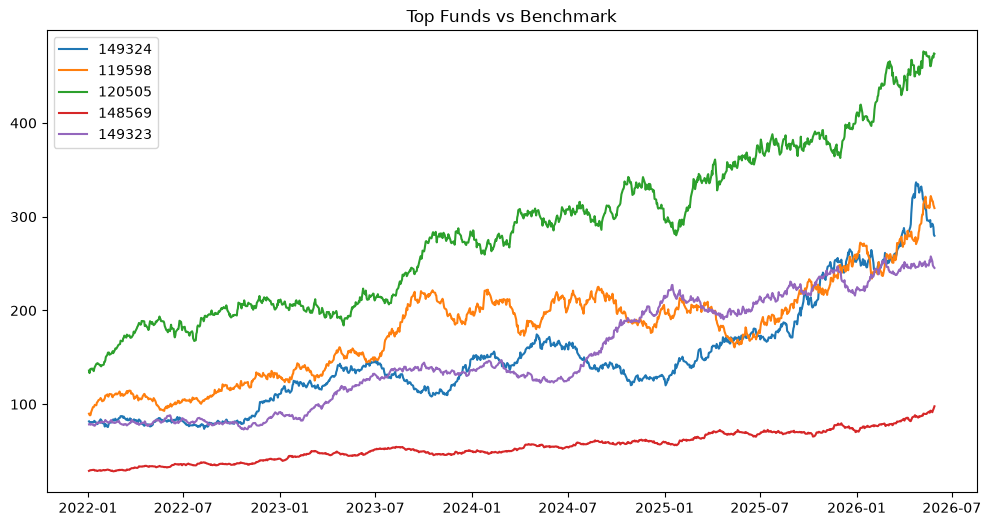

In [15]:
top5 = score.head(5)

plt.figure(figsize=(12,6))

for fund in top5["amfi_code"]:

    temp = nav[
        nav["amfi_code"] == fund
    ]

    plt.plot(
        temp["date"],
        temp["nav"],
        label=str(fund)
    )

plt.legend()

plt.title(
    "Top Funds vs Benchmark"
)

plt.savefig(
    "../reports/benchmark_comparison.png"
)

plt.show()